In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from math import ceil
from pylab import rcParams
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score as acu
from inspect import getfullargspec

%matplotlib inline
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = 16, 8

pd.options.display.max_columns = 100

In [42]:
train_data = pd.read_csv('data/train.csv')

train_data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
571,572,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.00,2,0,11769,51.4792,C101,S
751,752,1,3,"Moor, Master. Meier",male,6.00,0,1,392096,12.4750,E121,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S
530,531,1,2,"Quick, Miss. Phyllis May",female,2.00,1,1,26360,26.0000,NaN,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
510,511,1,3,"Daly, Mr. Eugene Patrick",male,29.00,0,0,382651,7.7500,NaN,Q
638,639,0,3,"Panula, Mrs. Juha (Maria Emilia Ojala)",female,41.00,0,5,3101295,39.6875,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.1333,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.00,0,0,SOTON/OQ 392076,7.0500,NaN,S
99,100,0,2,"Kantor, Mr. Sinai",male,34.00,1,0,244367,26.0000,NaN,S


## Описание датасета
* PassengerId: Уникальный индекс/номер строки. Начинается с 1 (для первой строки) и увеличивается на 1 для каждой следующей. Рассматриваем его как индентификатор строки и, что логично, идентификатор пассжира (т.к. для каждого пассажира в датасете представлена только одна строка).
* Survived: Признак, показывающий был ли спасен данный пассажир или нет. 1 означает, что удалось выжить, и 0 - не удалось спастись.
* Pclass: Класс билета. 1 - означает Первый класс билета. 2 - означает Второй класс билета. 3 - означает Третий класс билета.
* Name: Имя пассажира. Имя также может содержать титулы и обращения. "Mr" для мужчин. "Mrs" для женщин. "Miss" для девушек (тут имеется в виду что для тех, кто не замужем, так было принято, да и сейчас тоже, говорить в западном обществе). "Master" для юношей.
* Sex: Пол пассажира. Либо мужчины (=Male) оибо женщины (=Female).
* Age: Возраст пассажира. "NaN" значения в этой колонке означают, что возраст данного пассажира отсутствует/неизвестен/или не был записанv в датасет.
* SibSp: Количество братьев/сестер или супругов, путешествующих с каждым пассажиром.
* Parch: Количество родителей детей (Number of parents of children travelling with each passenger).
* Ticket: Номер билета.
* Fare: Сумма, которую заплатил пассажир за путешествие.
* Cabin: Номер каюты пассажира. "NaN" значения в этой колонке указавает на то, что номер каюты данного пассажира не был записан.
* Embarked: Порт отправления данного пассажира.

## Exploratory data analysis

Вывод всех колонок, а не только числовых include='all'. Транспонирование: Если столбцов много, вывод получается длинным и неудобным. Добавьте .T в конце, чтобы поменять строки и столбцы местами:

In [43]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
train_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [45]:
class DataFrame(pd.DataFrame):
    """расширение DataFrame"""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
            
    @property
    def _constructor(self):
        return DataFrame
        
    @property    
    def columns_num(self):
        """количественные признаки"""
        return self[self.columns.tolist()].select_dtypes(include=['uint8', 'int32', 'int64', 'float32', 'float64']).columns.tolist()
        
    @property    
    def columns_cat(self):
        """номинативные признаки"""
        return self[self.columns.tolist()].select_dtypes(include=['object', 'category']).columns.tolist()
    
    @property    
    def columns_bin(self):
        """бинарные признаки"""
        return self[self.columns.tolist()].select_dtypes(include=['bool']).columns.tolist()    
    
    def columns_except(self, columns, excepts):
        return self[[item for item in columns if item not in excepts]]

In [46]:
class DataPipeline:     
    def __init__(self, **kwargs):
        """Инициализация класса"""                 
        # уровень стат значимости
        self.alpha = 0.05
        # срнднйи уровень корреляции
        self.corr = 0.7
        # объясненная дисперсия компонента
        self.varatio = 0.8
        # пороговое значение в три сигмы
        self.threshold = 3    
        # пропорции деления набора
        self.test_size = 0.33
        
        # параметры класса
        for key, value in kwargs.items():
            setattr(self, key, value)    
            
        assert self.target is not None                  
        assert self.feature is not None                  
            
        # загрузка обучения    
        assert self.train_file is not None
        self.train_data = DataFrame(pd.read_csv(self.train_file))
        # удаляем id        
        self.train_PassengerId = self.train_data["PassengerId"]
        self.train_data.drop("PassengerId", axis=1, inplace=True, errors="ignore")                            
        # загрузка теста
        assert self.test_file is not None                           
        self.test_data = DataFrame(pd.read_csv(self.test_file))                
        # удаляем id        
        self.test_PassengerId = self.test_data["PassengerId"]
        self.test_data.drop("PassengerId", axis=1, inplace=True, errors="ignore")                                    
    
    def sc_data(func):
        """Декоратор стандартизации"""
        def wrapper(self):                                 
            # стандартизация обучения                    
            self.sc_train_data = func(self, self.train_data)                        
            # нормированная целевая переменная
            #self.train_data[self.target] = self.sc_train_data[self.target]
            # исключение целевой переменной из количественных признаков            
            column = self.sc_train_data.columns_except(self.sc_train_data.columns_num, self.target).columns                                    
            # стандартизатор                                
            scaler = StandardScaler()            
            # стандартизация признаков                             
            self.sc_train_data = DataFrame(pd.concat([DataFrame(scaler.fit_transform(self.sc_train_data[column]), columns=column),\
                                                      self.sc_train_data[self.sc_train_data.columns_cat]], axis=1))                                        
            
            print("train resize")             
            # понижение размерности                   
            self.sc_train_data = DataFrame(self._resize_(self.sc_train_data))
                        
            # стандартизация теста            
            self.sc_test_data = func(self, self.test_data)                             
            # стандартизация признаков            
            self.sc_test_data = DataFrame(pd.concat([DataFrame(scaler.transform(self.sc_test_data[self.sc_test_data.columns_num]),\
                                                     columns=self.sc_test_data.columns_num),\
                                                     self.sc_test_data[self.sc_test_data.columns_cat]], axis=1))                                     
            
            print("test resize")         
            # понижение размерности            
            self.sc_test_data = DataFrame(self._resize_(self.sc_test_data))                      
                        
        return wrapper    
    
    @sc_data
    def transform(self, data):       
        """Трансформация данных"""               
        # заменяем inf на nan тогда моедль сможет их предсказать
        data.replace([np.inf, -np.inf], np.nan, inplace = True)
        
        # добавление признаков
        data = self.feature.create(data, self.target)                                  
            
        # обработка номинальных признаков
        for item in data.columns_cat + data.columns_bin:        
            data = self._transform_cat_(data, item)          
        
        # обработка количественных признаков
        for item in data.columns_num:
            data = self._transform_num_(data, item)  
        
        return data
            
    def _transform_cat_(self, data, column):
        """Трансформация номинальных признаков"""                
        # заменяем пропуски модой                                   
        data[column] = data[column].fillna(data[column].mode()[0])                    
        # кодируем признак
        data[column] = LabelEncoder().fit_transform(data[column])                
        # возвращаем категаориальный тип
        data[column] = data[column].astype('category')
        
        return data
        
    def _transform_num_(self, data, column):        
        """Трансформация количественных признаков"""        
        
        # пробуем предсказать пропуски                        
        cdata = DataFrame(data.copy()) 
        # запомнинание пропусков        
        cdata['isna'] = np.where(cdata[column].isna(), True, False)           
        
        # заполнение пропусков в копии, т.к моедель не работает с ними
        for item in cdata.columns_cat:            
            cdata[item] = cdata[item].fillna(cdata[item].mode())                
        for item in cdata.columns_num:
            cdata[item] = cdata[item].fillna(cdata[item].mean())        

        # предсказание пропусков если можно сформировать обучающий и тестовый набор
        if True in cdata['isna'].values and False in cdata['isna'].values:            
            # используем простую модель
            model = LinearRegression()
            # формируем тестовый и обучающий набор
            X_test = cdata.columns_except(cdata.columns, column)[cdata['isna']==True]
            X_train = cdata.columns_except(cdata.columns, column)[cdata['isna']==False]
            y_train = cdata[cdata['isna']==False][column]                    
            # обучение модели
            model.fit(X_train, y_train)
            # выполняем предсказание пропущенного прзнака        
            data.loc[cdata['isna'], [column]] = model.predict(X_test)         
            
        cdata = DataFrame(data.copy()) 
        # обработка выбрасов, вычисляем z-Score в цикле пока не подавим их все               
        while column != self.target and not data[column].isin([0, 1]).all():            
            z = np.abs(stats.zscore(cdata[column]))
            # если z-Score определен, сохраняем результат
            # винсоризацию крайнее средство если не помог z-Score, модели очень чувствительны к большим числам-выбросам. 
            # винзоризация помогает модели не «отвлекаться» на аномалии, сохраняя при этом информацию о том, 
            # что в этой строке было какое-то экстремальное значение.                        
            if not np.isnan(z).any():                 
                data[column] = cdata[column]            
            else:                 
                data[column] = winsorize(data[column], limits=[0.0, 0.1])                             
            # если выбрасов нет, выходим
            if not z[z > self.threshold].any():
                break                                
            # среднее если данные имеют нормальное распределение, иначе медиана         
            if stats.shapiro(cdata[column].values.reshape(-1))[1] > self.alpha:                         
                cdata.loc[z > self.threshold, column] = cdata[column].mean()                            
            else:                            
                cdata.loc[z > self.threshold, column] = cdata[column].median()                                                                                           
            
        return data          
    
    def _resize_(self, data, level = 0):
        """понижение размерности"""           
        # корреляционная матрица                               
        m_corr = data.corr()
        
        if data.equals(self.sc_train_data):
            self.m_corr = list()
        
        if level not in range(len(self.m_corr)):            
            self.m_corr.insert(level, m_corr)            
        else:            
            m_corr = self.m_corr[level]    
        
        for item in m_corr.columns:                        
            # поиск взаимокорреляции признаков по матрице
            column = list(m_corr[np.abs(m_corr[item]) > self.corr].index)
            # корреляция не с самим собой и не одни компоненты 
            if len(column) > 1 and not all('component' in item for item in column):
                dim_reducer = PCA(n_components=1, random_state=42)                
                components = dim_reducer.fit_transform(data[column])                
                # уровень дисперсии достаточен для свертывания
                if dim_reducer.explained_variance_ratio_ >= self.varatio:
                    data = DataFrame(pd.concat([data.drop(column, axis=1),\
                                                pd.DataFrame(data = components, columns = [f'component_{level}'])], axis=1))                                                                                                
                    # результат свертки
                    print(f'{column} -> component_{level} var:{dim_reducer.explained_variance_ratio_}')
                    # рекурсивный поиск компонент
                    return self._resize_(data, level + 1)               
        return data                
    
    def split(self, X, y):
        """Разделение набора"""         
        if not(hasattr(self, 'X_train') and hasattr(self, 'X_valid') and hasattr(self, 'y_train') and hasattr(self, 'y_valid')):
            self.X_train, self.X_valid, self.y_train, self.y_valid = train_test_split(X, y, test_size=self.test_size, random_state=42)
        
        return self.X_train, self.X_valid, self.y_train, self.y_valid
    
    def search_param(self, model, data):
        """Поиск гиперпараметров"""        
        params = {
            'criterion': ['gini', 'log_loss', 'entropy'],
            'n_estimators': [item for item in range(10, 100, 10)],            
            'max_depth': [item for item in range(1, 16, 2)],
            'max_features': [item for item in range(1, 10, 2)],
            'min_samples_leaf': [item for item in range(1, 10, 2)],
        }

        clf = GridSearchCV(
            estimator=model,
            param_grid=params,            
            scoring='accuracy',
            n_jobs=-1,
            cv=5
        )              
        # формируем X и y из обучающего набора
        X_train, X_valid, y_train, y_valid = self.split(data.columns_except(data.columns, self.target), data[self.target])
        # искать праметры лучше на всеъ данных
        clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]))
        
        return clf.best_params_, DataFrame(clf.cv_results_)
    
    def fit(self, model, data):
        """Обучение модели"""                                   
        # разделение набора на обучающий и проверочный
        X_train, X_valid, y_train, y_valid = self.split(data.columns_except(data.columns, self.target), data[self.target])        
        # обучать модель
        model.fit(X_train, y_train)
        
        return model
        
    def predict(self, model, data):
        """Предсказание зависимой переменной"""                     
        return model.predict(data)    
    
    def importances(self, model, data):
        """оценка признаков модели"""                                
        return pd.DataFrame(zip(data.columns_except(data.columns, self.target).columns, model.feature_importances_),\
                            columns = ['name', 'value']).sort_values(by = 'value', ascending = False)                          

    def scatterplot(self, model, data):
        if isinstance(model, RandomForestClassifier):
            self.scatterplotAC(model, data)
        elif isinstance(model, RandomForestRegressor):
            self.scatterplotR2(model, data)       
        else:
            raise ValueError(f"{type(model)} not support")
            
    def scatterplotAC(self, model, data):
        estimators = data.groupby('param_n_estimators').agg(mean_test_score=('mean_test_score', 'max')).reset_index()        
        # Рисуем scatter plot для средних значений
        plt.subplot(121)
        plt.scatter(estimators['param_n_estimators'], estimators['mean_test_score'], color='red', label='Mean Accuracy')
        # Линия тренда
        plt.plot(estimators['param_n_estimators'], estimators['mean_test_score'], linestyle='--', alpha=0.5)                

        plt.title(f"Accuracy MAX {round(data['mean_test_score'].max(), 2)} vs Max Estimators")
        plt.xlabel('Max Estimators')
        plt.ylabel('Mean Test Accuracy')        

        depth = data.groupby('param_max_depth').agg(mean_test_score=('mean_test_score', 'max')).reset_index()
        plt.subplot(122)
        plt.scatter(depth['param_max_depth'], depth['mean_test_score'], color='red', label='Mean Accuracy')
        # Линия тренда
        plt.plot(depth['param_max_depth'], depth['mean_test_score'], linestyle='--', alpha=0.5)        

        plt.title(f"Accuracy MAX {round(depth['mean_test_score'].max(), 2)} vs Max Depth")
        plt.xlabel('Max Depth')
        plt.ylabel('Mean Test Accuracy')   
        
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    
    def scatterplotR2(self, model, data):
        """график scatterplot качесива модели"""    
        X_train, X_valid, y_train, y_valid = self.split(data.columns_except(data.columns, self.target), data[self.target])

        y_pred = self.predict(model, X_train)

        plt.subplot(121)
        plt.xlabel('Predicted values')
        plt.ylabel('True values')        
        plt.title(f"train R2:{round(R2(y_train, y_pred), 3)}")
        sns.scatterplot(x = y_train, y = y_pred)
        
        y_pred = self.predict(model, X_valid)        

        plt.subplot(122)
        plt.xlabel('Predicted values')
        plt.ylabel('True values')                
        plt.title(f"valid R2:{round(R2(y_valid, y_pred), 3)}")
        sns.scatterplot(x = y_valid, y = y_pred)

        plt.show()           
        
    def plot(self, data):      
        """график plot"""                    
        data.columns_except(data.columns, [self.target]).hist(figsize=(16,12), bins=20, grid=False);        
        
        plt.figure(figsize = (16, 8))
        sns.distplot(data[self.target], bins=50)  
        
        target_mean = round(data[self.target].mean(), 2)
        target_median = data[self.target].median()
        target_mode = data[self.target].mode()[0]        

        print(target_mean,target_median,target_mode)

        y = np.linspace(0, 0.000005, 10)
        plt.plot([target_mean] * 10, y, label='mean', linestyle=':', linewidth=4)
        plt.plot([target_median] * 10, y, label='median', linestyle='--', linewidth=4)
        plt.plot([target_mode] * 10, y, label='mode', linestyle='-.', linewidth=4)

        plt.title(f'Distribution of {self.target}')
        plt.legend()            
        plt.show()        

    def boxplot(self, data):
        """график box-plot"""                           
        data.boxplot(column = data.columns_num, grid = False, rot = 45)
        
    def corrplot(self, data):
        """график корреляции"""              
        plt.title('Корреляционная матрица')
        sns.heatmap(data.corr(), annot = True)
        plt.show()  

In [47]:
class Features:
    """Генератор признаков"""    
    def create(self, data, target):                                                   
        # Заполнение пропусков
        data['Cabin'] = data['Cabin'].fillna('U')
        # Извлечение первой буквы (палубы)
        data['Deck'] = data['Cabin'].str.slice(0,1)  
        # Удаление признака по причине отсутсвия его влияния на целевую переменную 
        data.drop("Cabin", axis=1, inplace=True, errors="ignore")
        
        data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
        data.drop("SibSp", axis=1, inplace=True, errors="ignore")
        data.drop("Parch", axis=1, inplace=True, errors="ignore")                            

        data = pd.get_dummies(data, columns=['Embarked'])  
        
        # preprocessor = ColumnTransformer(
        #     transformers=[
        #     ('num', StandardScaler(), data.columns_num),
        #     ('cat', OneHotEncoder(drop='first', sparse_output=False), 'Embarked')],
        #      remainder='drop'
        # )            
                
        # X_data_transformed = preprocessor.fit_transform(data)                    
        # encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)    

        # print(encoded_cols)
        
        # all_cols = num_cols + list(encoded_cols)
        # return DataFrame(X_data_transformed, columns=all_cols)        
        
        return DataFrame(data)    

In [48]:
# создамие конвейера
pipeline = DataPipeline(feature=Features(), train_file="data/train.csv", test_file="data/test.csv", target='Survived')

### Визулизация признаков и целевой переменной.

0.38 0.0 0


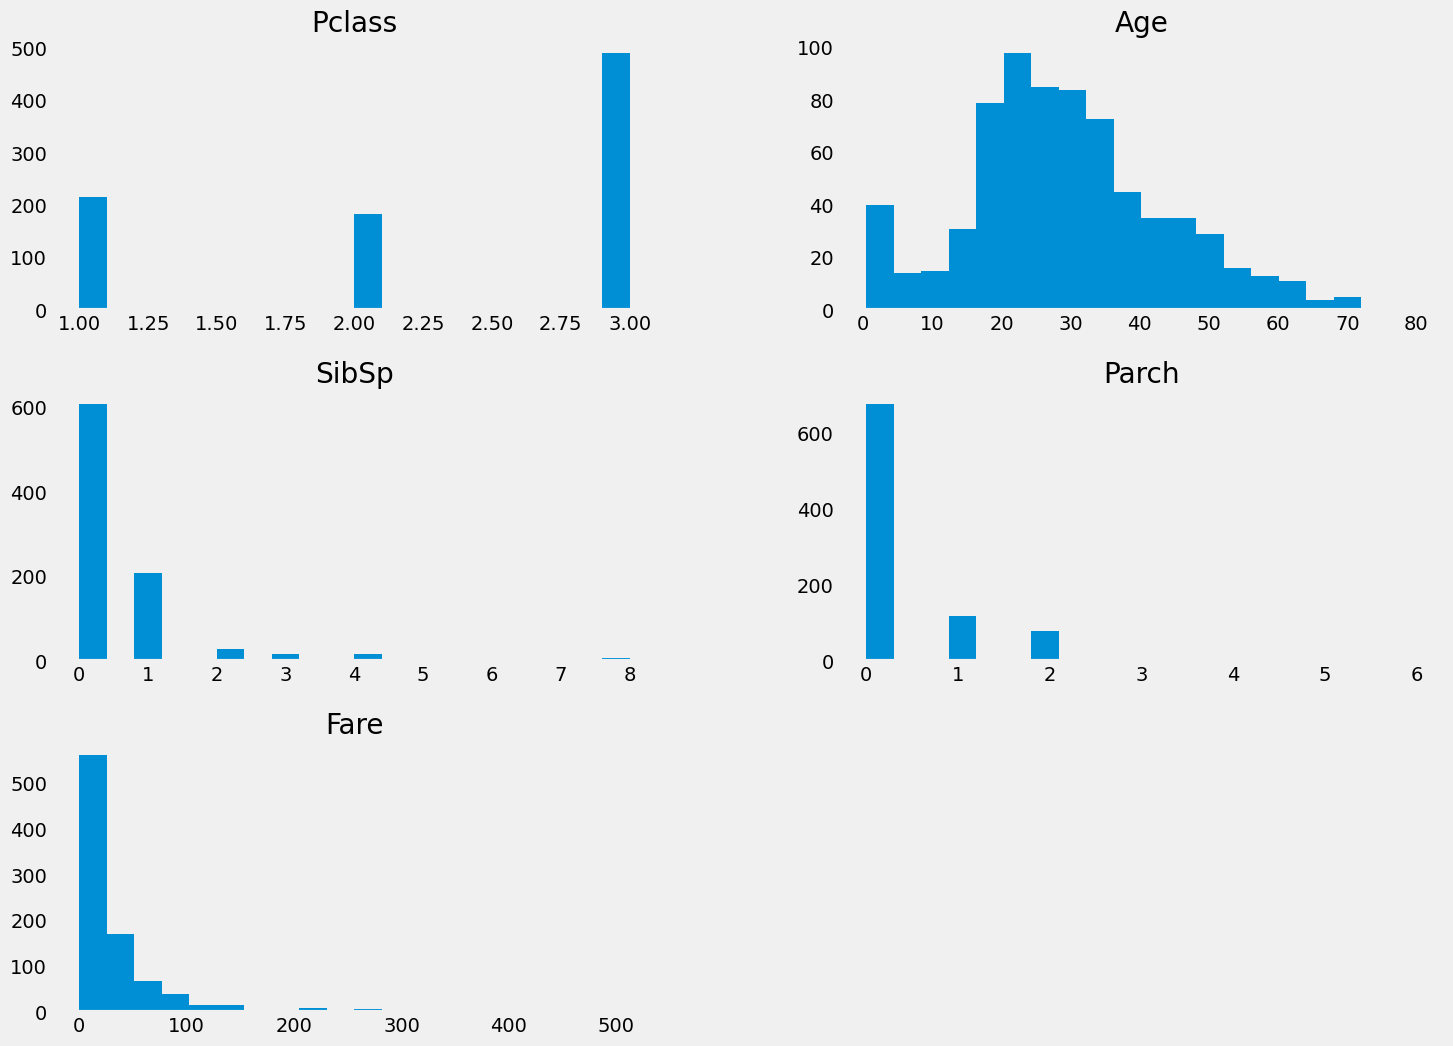

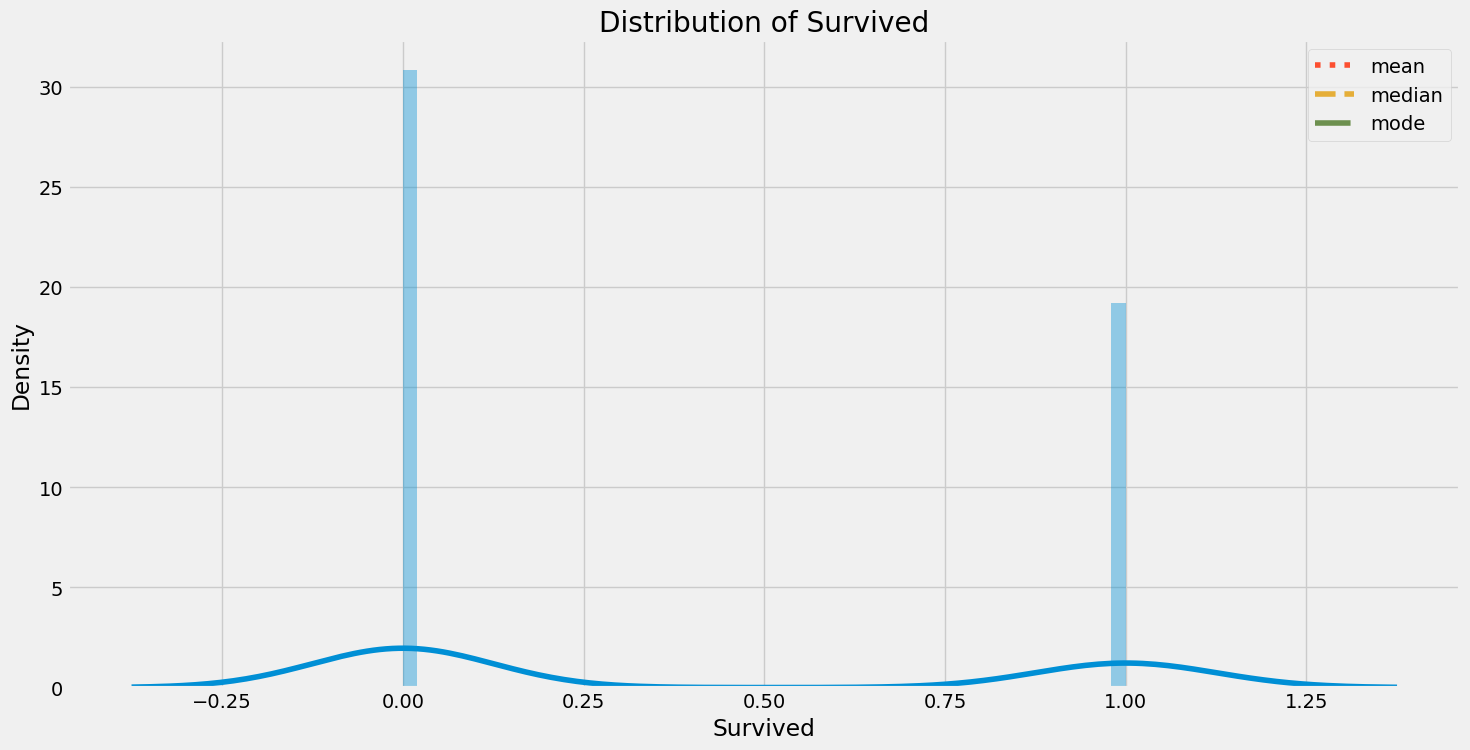

In [49]:
pipeline.plot(pipeline.train_data)

In [50]:
# подготовка признаков
pipeline.transform()

train resize
['Pclass', 'Deck'] -> component_0 var:[0.94285343]
['Embarked_C', 'Embarked_S'] -> component_1 var:[0.89144763]
test resize
['Pclass', 'Deck'] -> component_0 var:[0.914663]
['Embarked_C', 'Embarked_S'] -> component_1 var:[0.88521925]


In [51]:
# масштабированный и нормализованный набор
df = DataFrame(pd.concat([pipeline.sc_train_data, pipeline.train_data[pipeline.target]], axis=1))

In [52]:
DataFrame(pd.concat([pipeline.train_PassengerId, df], axis=1)).sample(5)

,PassengerId,Age,Fare,FamilySize,Name,Sex,Ticket,Embarked_Q,component_0,component_1,Survived
600,601,-0.398472,1.654800,-0.597035,391,0,142,0,1.106752,0.333517,1
548,549,0.296654,0.804732,2.317805,294,1,423,0,1.476897,0.333517,0
569,570,0.219418,-0.858750,-0.597035,416,1,415,0,1.476897,0.333517,1
768,769,-0.022417,1.280639,0.860385,553,1,469,1,1.476897,-0.431733,0
443,444,-0.089527,-0.183185,-0.597035,679,0,116,0,1.106752,0.333517,1


0.38 0.0 0


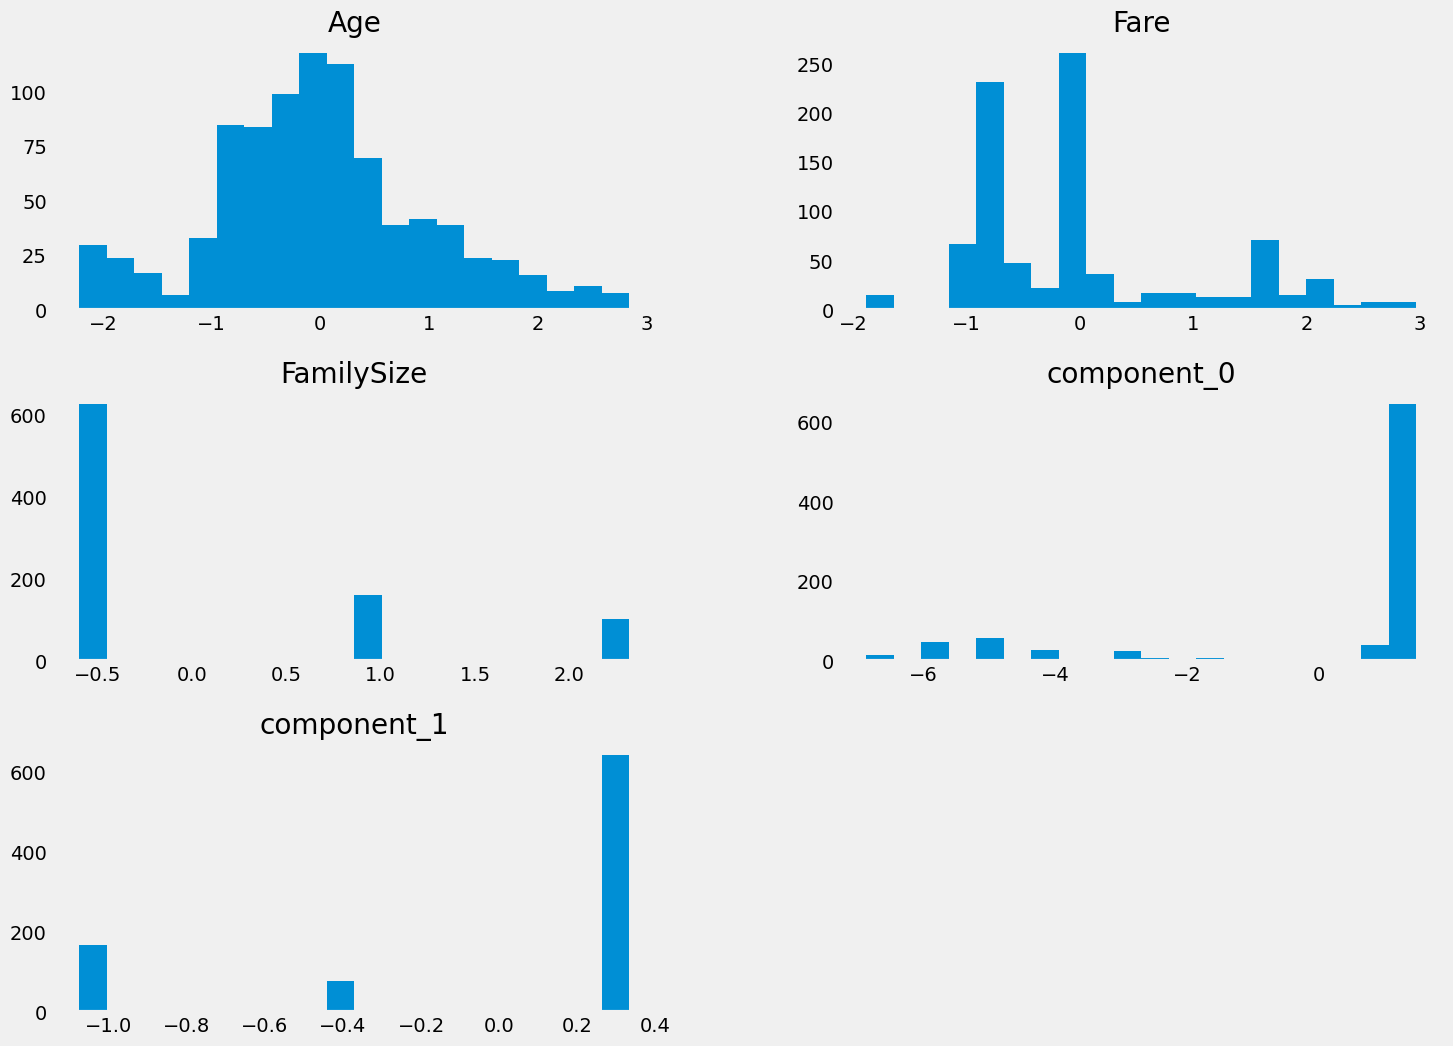

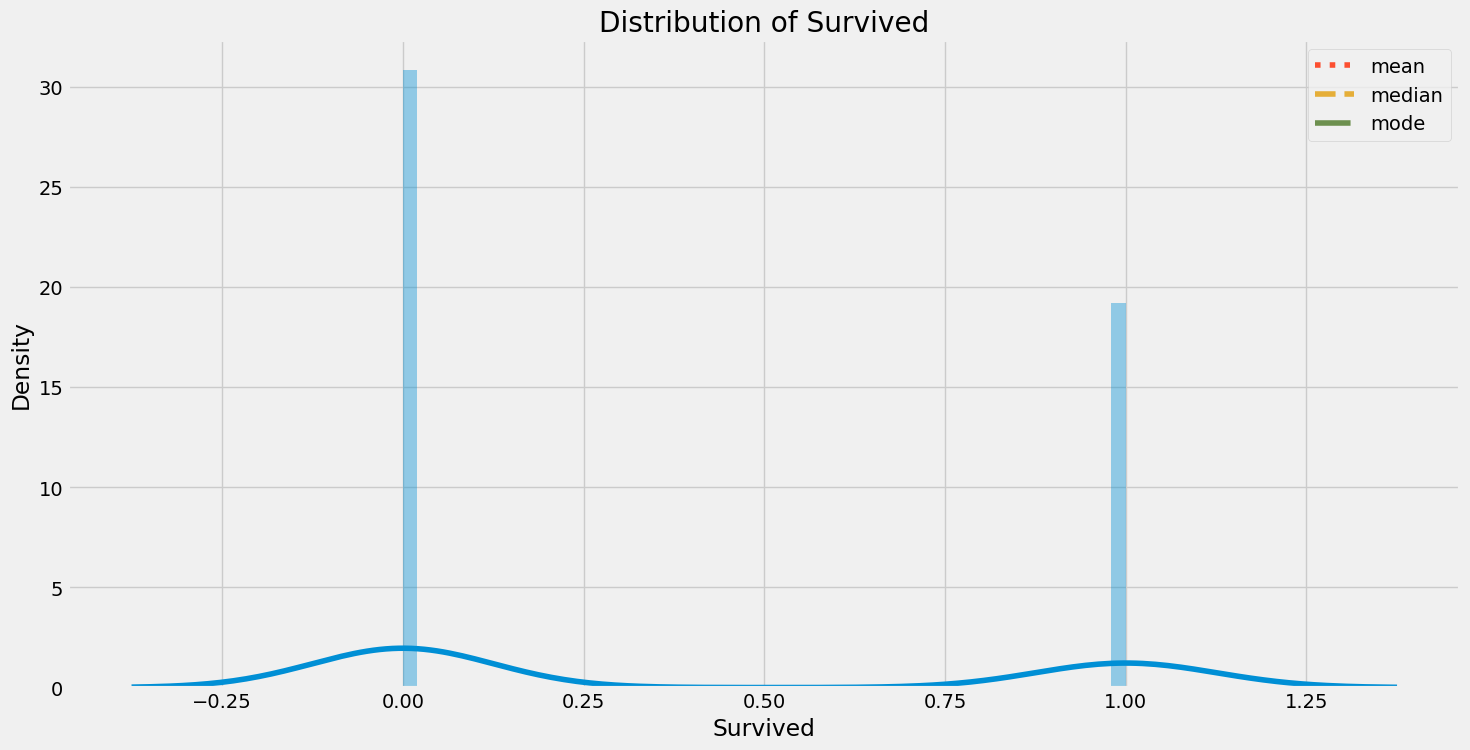

In [53]:
# распределение количественных признаков в исходных данных 
# целевой переменной и ее статистические данные
pipeline.plot(df)

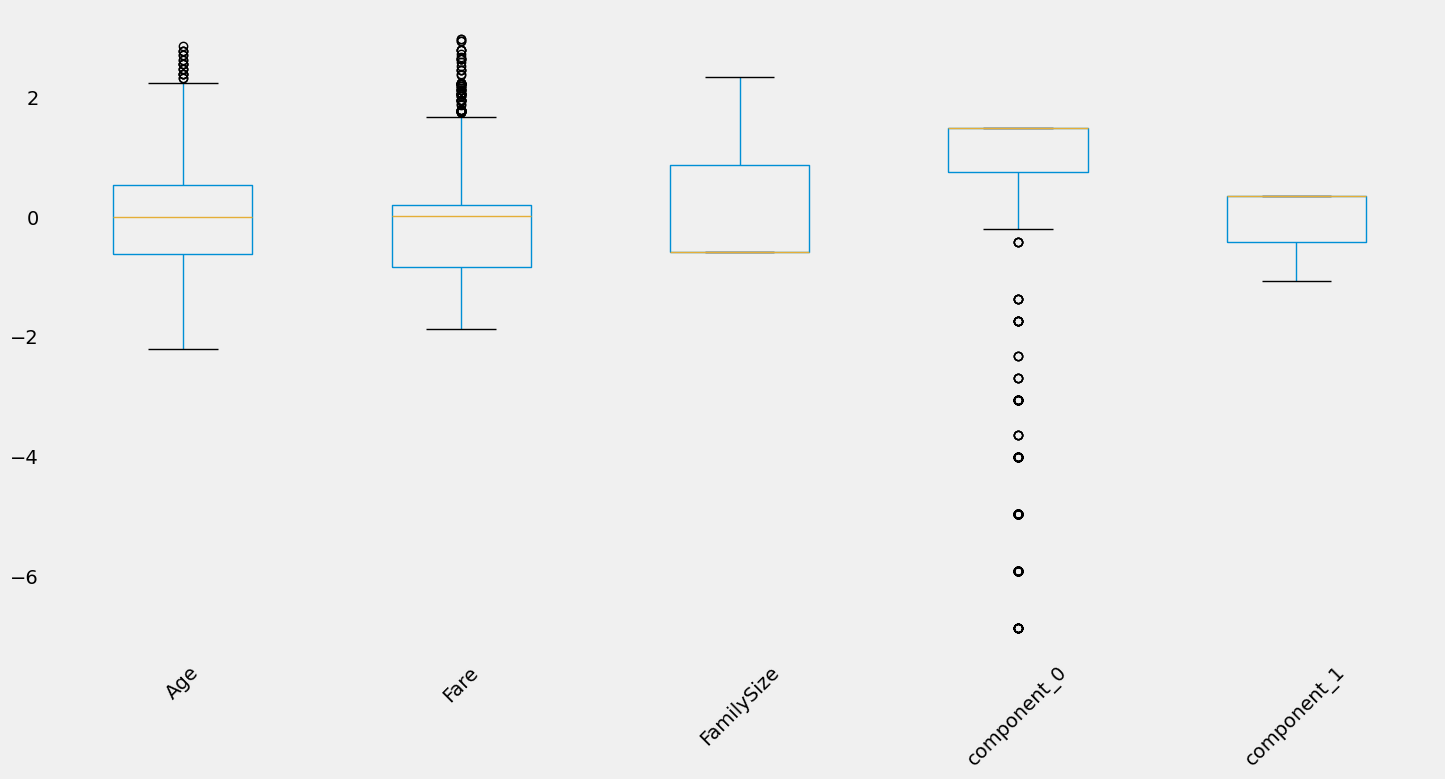

In [54]:
# визуализация выбросов после обработки признаков
pipeline.boxplot(pipeline.sc_train_data)

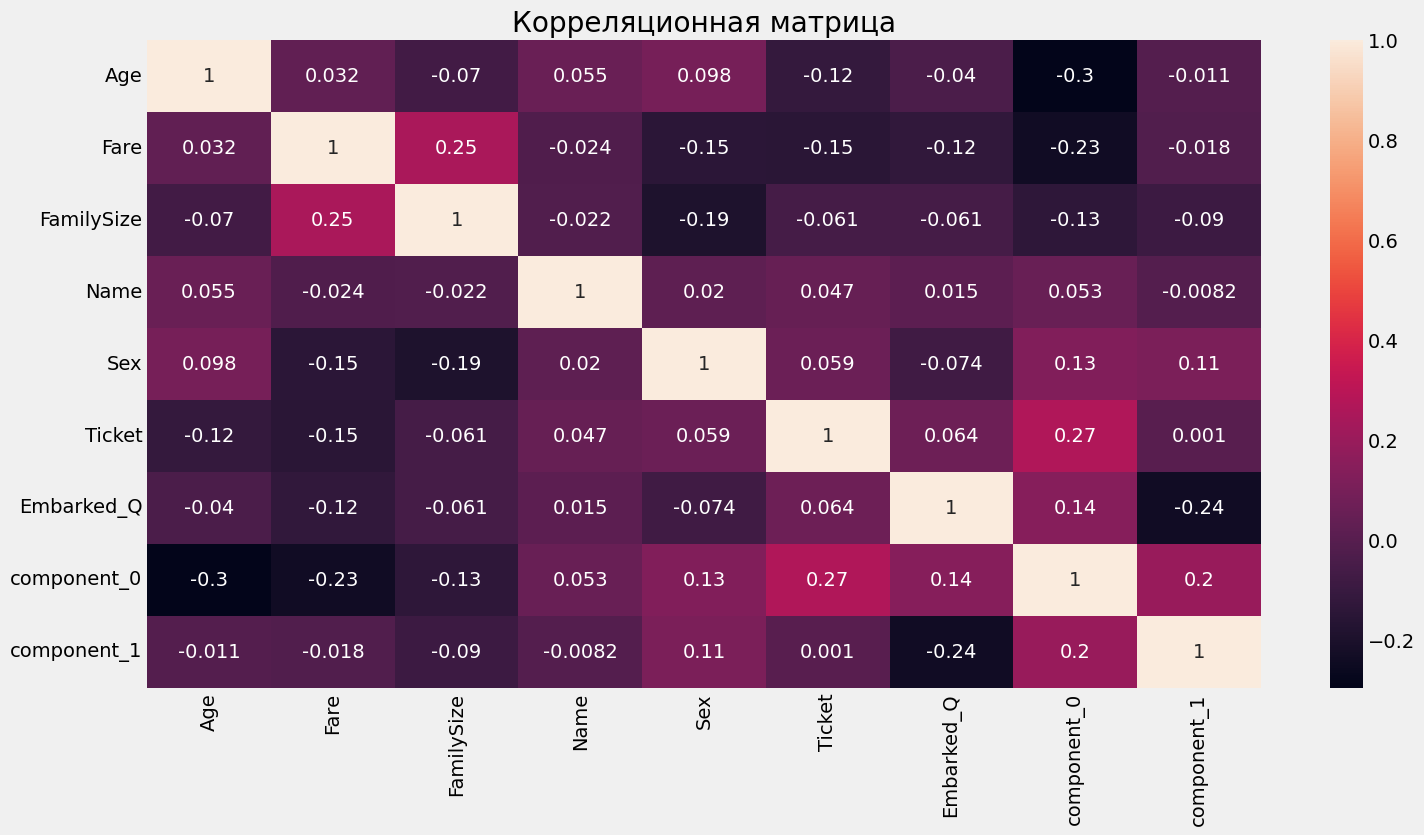

In [55]:
# корреляция признаков с целевой переменной их сильные взаимокорреляции устранены PCA
pipeline.corrplot(pipeline.sc_train_data)

In [56]:
%%time
# определение оптимальных гипрепараметров модели
params, cv_result = pipeline.search_param(RandomForestClassifier(random_state=42), df)
# лучшие гиперпараметры модели
print(params)

{'criterion': 'gini', 'max_depth': 9, 'max_features': 3, 'min_samples_leaf': 1, 'n_estimators': 50}
CPU times: total: 1min 10s
Wall time: 6min 58s


params = {'criterion': 'gini', 'max_depth': 1, 'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 20}

In [57]:
# обучение модели
model = pipeline.fit(RandomForestClassifier(**params), df)

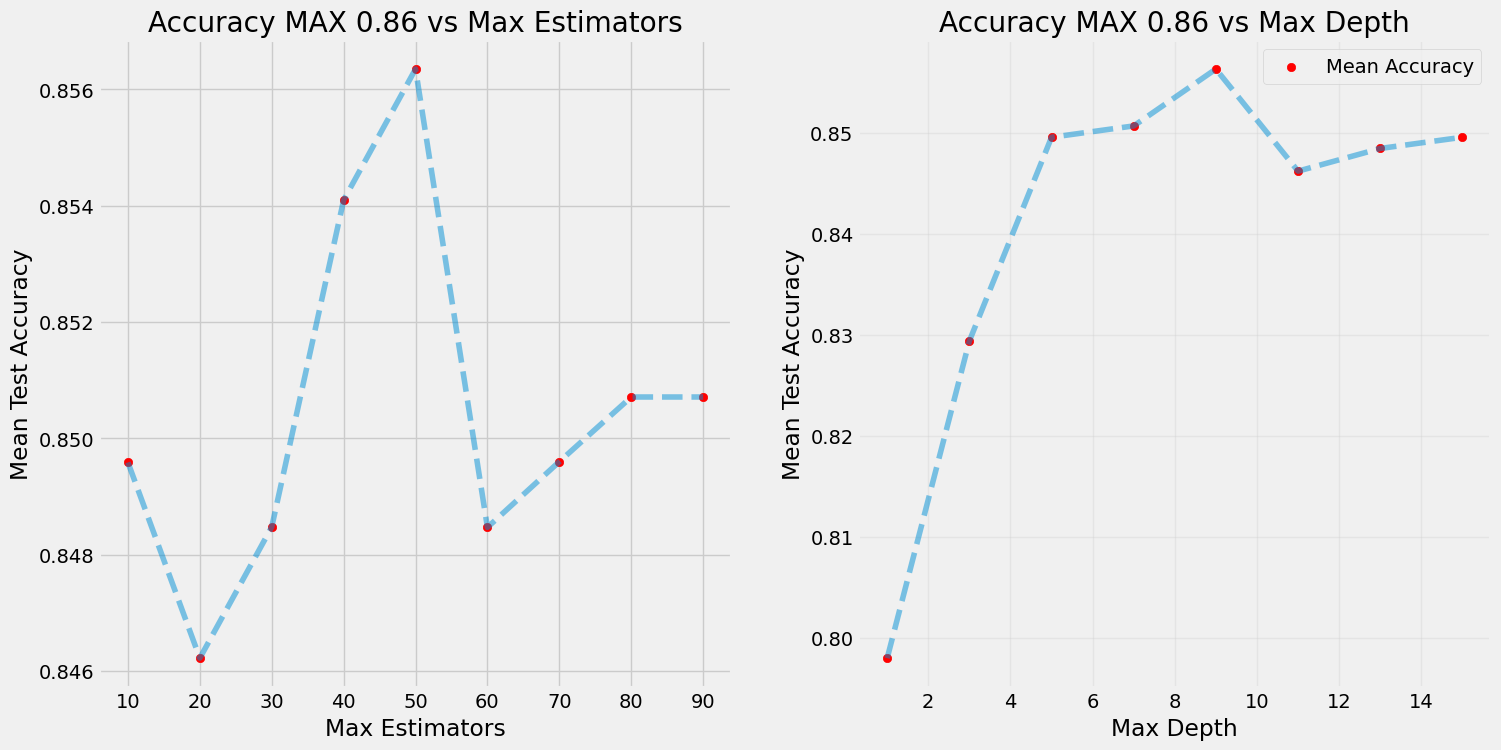

In [58]:
# оценка результата обучения
pipeline.scatterplot(model, cv_result[cv_result['param_criterion']==params['criterion']])

In [59]:
# влияние признаков на процесс обучения
pipeline.importances(model, df)

,name,value
4,Sex,0.241102
5,Ticket,0.171510
0,Age,0.143452
7,component_0,0.134415
1,Fare,0.121382
3,Name,0.116519
8,component_1,0.034000
2,FamilySize,0.028861
6,Embarked_Q,0.008759


In [60]:
# предсказание целевой переменой в test
pd.concat([pipeline.test_PassengerId, pipeline.test_data, pd.DataFrame(data = pipeline.predict(model, pipeline.sc_test_data),\
                                            columns = [pipeline.target])], axis=1)   

,PassengerId,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Deck,FamilySize,Survived
0,892,3,"Kelly, Mr. James",male,34.5,330911,7.8292,Q,U,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,S,U,2,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,Q,U,1,0
3,895,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,S,U,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,S,U,3,1
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,A.5. 3236,8.0500,S,U,1,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,PC 17758,108.9000,C,C,1,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,SOTON/O.Q. 3101262,7.2500,S,U,1,0
416,1308,3,"Ware, Mr. Frederick",male,NaN,359309,8.0500,S,U,1,0
